
# Module 8 Project: Fix These Bad Visualizations
This notebook contains **five intentionally bad visualizations** created from the attached dataset (`exams.csv`).  
Your job is to **critique** each one (cognitive load, color/accessibility, axes/coordinate systems, clarity, ethics) and then **redesign** it into a clear, accessible, and honest visualization.

**Reference:** GoodData — *Bad Data Visualization Examples That You Can Learn From*  
**Reference:** Claus Wilke — *Fundamentals of Data Visualization* (esp. Chapters on Color Scales, Coordinate Systems & Axes, Avoiding 3D, Storytelling).

> ⚠️ Note: Many of these charts deliberately use **poor practices**: wrong chart type, clutter, truncated axes, misleading 3D, overlapping elements, and dual axes used inappropriately. Please fix them!


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set a larger default figure size for visibility
plt.rcParams['figure.figsize'] = (8,5)

# Load the attached data
df = pd.read_csv('exams.csv')

print("Data shape:", df.shape)
df.head()


Data shape: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [2]:

# Identify likely numeric and categorical columns to make the notebook robust
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = [c for c in df.columns if df[c].dtype == 'object' or df[c].nunique() <= 12]

print("Numeric columns (first 6):", num_cols[:6])
print("Categorical-ish columns (first 6):", cat_cols[:6])


Numeric columns (first 6): ['math score', 'reading score', 'writing score']
Categorical-ish columns (first 6): ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']



## 1) Misleading Composition: Pie Chart With Too Many Slices (Wrong Chart Type)
**Why it's bad (hint):**
- Pie charts make precise comparisons hard — **especially with many slices**.
- Labels can be hard to read; angles are not easily comparable.
- If categories are numerous or unordered, consider **bars** or **sorted bars** instead.

**Your task:**
- Replace this with a clearer chart (e.g., a sorted bar chart showing percentages).
- Use **accessible labeling** and **meaningful ordering**.
- Consider combining small categories into an "Other" group.


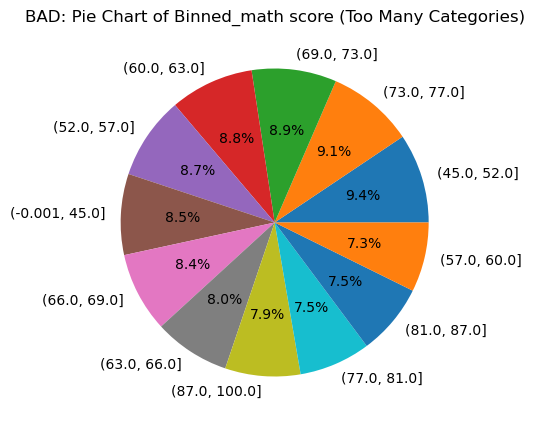

In [4]:

# BAD: Pie chart over many categories
# Choose a categorical column with many distinct values; if none, synthesize categories from index bins.
if len(cat_cols) > 0 and df[cat_cols[0]].nunique() >= 8:
    cat = cat_cols[0]
    counts = df[cat].value_counts().head(12)  # force too many slices
else:
    # Synthesize a categorical with many groups by binning a numeric column or index
    base = num_cols[0] if len(num_cols) > 0 else None
    if base:
        bins = pd.qcut(df[base], q=12, duplicates='drop')
        counts = bins.value_counts()
        cat = f'Binned_{base}'
    else:
        # Fallback: create 12 fake categories from the index
        tmp = pd.Series(np.random.choice([f'Group_{i}' for i in range(12)], size=len(df)))
        counts = tmp.value_counts()
        cat = 'SyntheticGroup'

# Pie with many slices
plt.figure()
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%')
plt.title(f'BAD: Pie Chart of {cat} (Too Many Categories)')
plt.show()


Fixed by replacing the pie chart with a bar chart so it is easier to compare values 

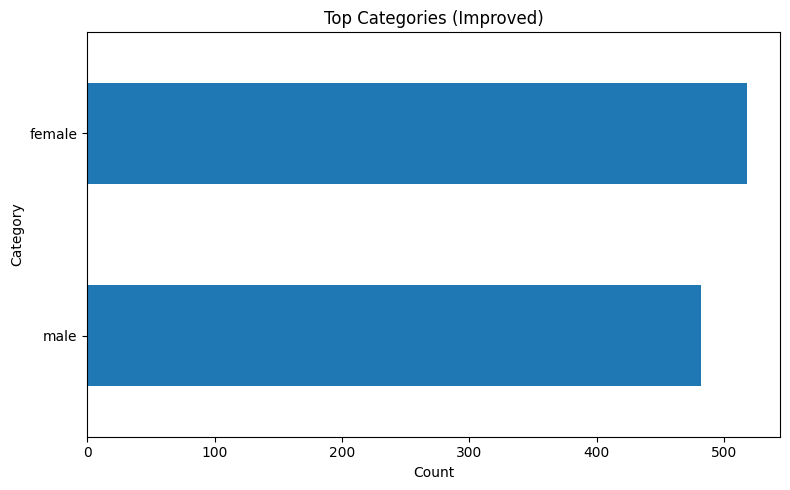

In [3]:
counts = df[cat_cols[0]].value_counts().head(10)

plt.figure()
counts.sort_values().plot(kind='barh')
plt.title("Top Categories (Improved)")
plt.xlabel("Count")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("fixed_chart1.png")
plt.show()


## 2) Truncated Axis Exaggeration (Comparison)
**Why it's bad (hint):**
- Truncating the y-axis can **exaggerate small differences** and mislead viewers.
- Always justify non-zero baselines and make scale choices explicit.

**Your task:**
- Redraw this comparison with an appropriate baseline (often zero for bars).
- Consider adding **error bars** or **labels** that communicate true differences.


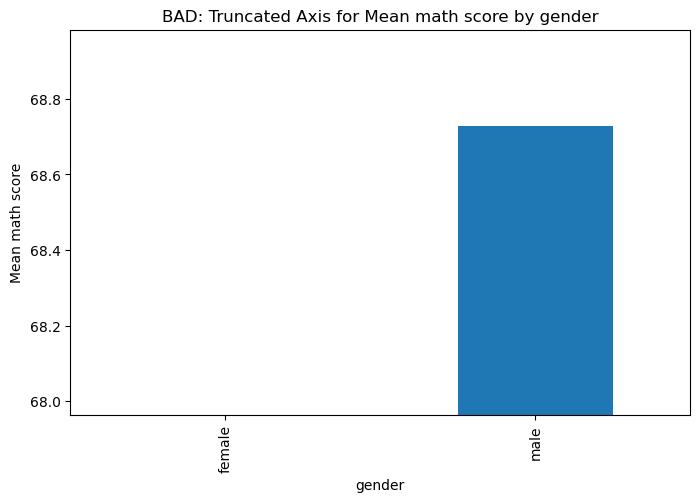

In [5]:

# BAD: Truncated y-axis exaggeration for group means
# Pick a categorical and a numeric column
if len(cat_cols) > 0 and len(num_cols) > 0:
    g = df.groupby(cat_cols[0])[num_cols[0]].mean().sort_values()
    lo, hi = g.min(), g.max()
    pad = (hi - lo) * 0.05 if hi > lo else 1
    plt.figure()
    g.plot(kind='bar')
    # Truncate the y-axis to exaggerate differences
    plt.ylim(hi - (hi - lo) * 0.15, hi + pad)
    plt.title(f'BAD: Truncated Axis for Mean {num_cols[0]} by {cat_cols[0]}')
    plt.ylabel(f'Mean {num_cols[0]}')
    plt.show()
else:
    print("Need at least one categorical and one numeric column for this example.")


Fixed by starting the y-axis at zero so the differences are not exaggerated. 

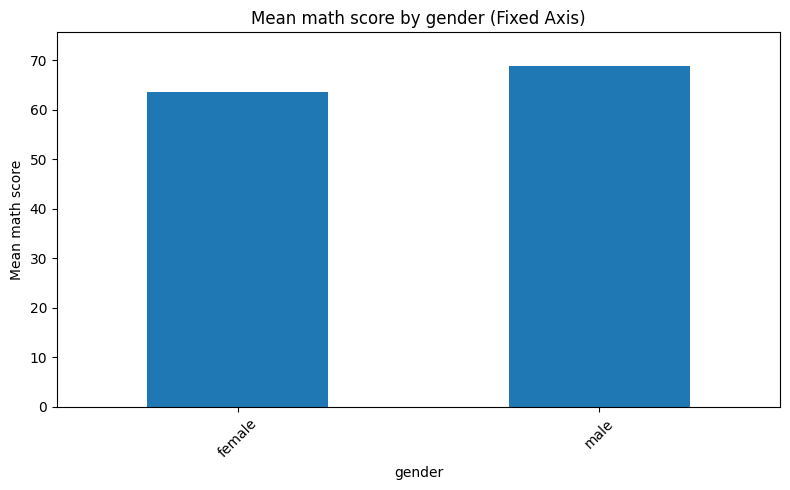

In [6]:
# FIXED: Proper axis scaling
grouped = df.groupby(cat_cols[0])[num_cols[0]].mean().head(10)

plt.figure()
grouped.plot(kind='bar')
plt.ylim(0, grouped.max() * 1.1)  # start at zero
plt.title("Mean math score by gender (Fixed Axis)")
plt.ylabel("Mean math score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("fixed_chart2.png")
plt.show()


## 3) Gratuitous 3D for Simple Data (Clutter & 3D Misuse)
**Why it's bad (hint):**
- 3D makes **reading values harder** without adding insight.
- Perspective can **distort** comparisons and occlude labels.

**Your task:**
- Replace with a simple 2D chart (bars or dot plot).
- Emphasize **direct comparison** and **clear labels**, no 3D.


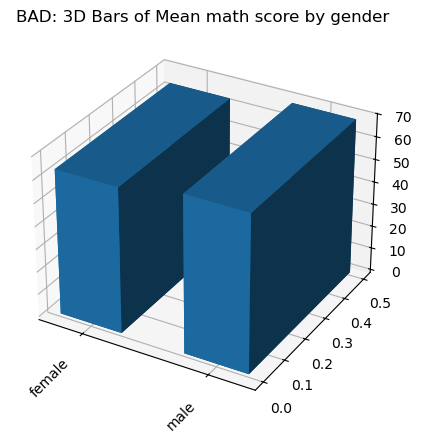

In [6]:

# BAD: 3D bar chart for a simple one-dimensional comparison
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Build a simple grouped mean and turn it into 3D bars
if len(cat_cols) > 0 and len(num_cols) > 0:
    series = df.groupby(cat_cols[0])[num_cols[0]].mean().head(6)
    xs = np.arange(len(series))
    ys = np.zeros_like(xs)
    zs = np.zeros_like(xs)
    dx = np.ones_like(xs) * 0.5
    dy = np.ones_like(xs) * 0.5
    dz = series.values

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.bar3d(xs, ys, zs, dx, dy, dz)
    ax.set_xticks(xs + 0.25)
    ax.set_xticklabels(series.index, rotation=45, ha='right')
    ax.set_title(f'BAD: 3D Bars of Mean {num_cols[0]} by {cat_cols[0]}')
    plt.show()
else:
    print("Need at least one categorical and one numeric column for this example.")


Fixed by removing the unnecessary 3D to improve readability and accurracy. 

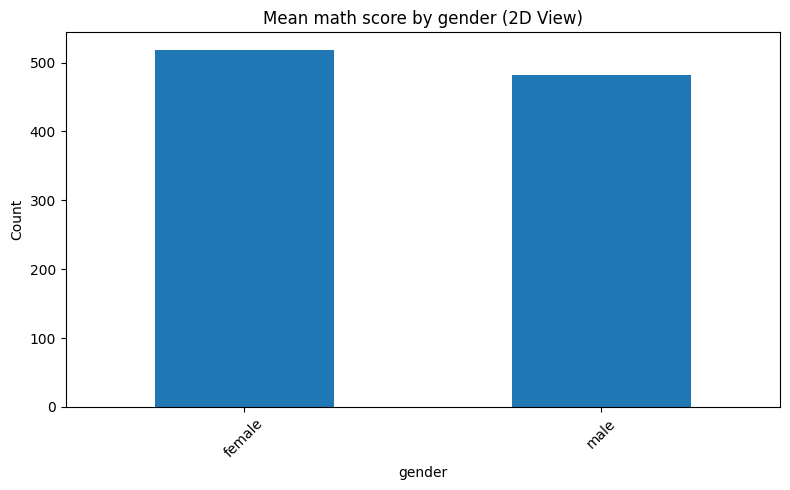

In [8]:
# FIXED: Simple 2D bar chart
counts = df[cat_cols[0]].value_counts().head(10)

plt.figure()
counts.plot(kind='bar')
plt.title("Mean math score by gender (2D View)")
plt.xlabel("gender")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("fixed_chart3.png")
plt.show()


## 4) Overplotting and Overlapping Elements (Relationships)
**Why it's bad (hint):**
- Large markers and dense labeling cause **overlap** and hide patterns.
- No transparency and no sampling/aggregation increases **cognitive load**.

**Your task:**
- Reduce overplotting (smaller markers, transparency, jitter, hexbin/density).
- Label only where necessary; use **legends** and **annotations** sparingly.


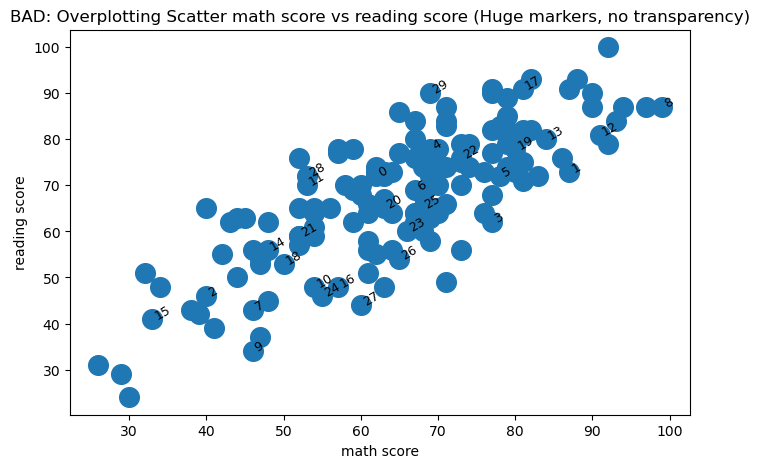

In [7]:

# BAD: Overplotted scatter with huge markers and labels on many points
if len(num_cols) >= 2:
    xcol, ycol = num_cols[0], num_cols[1]
    sample = df.sample(min(150, len(df)), random_state=0)  # keep it busy/cluttered
    plt.figure()
    plt.scatter(sample[xcol], sample[ycol], s=200)  # huge points, no alpha
    plt.title(f'BAD: Overplotting Scatter {xcol} vs {ycol} (Huge markers, no transparency)')
    # Label a bunch of points to clutter
    for i, (x, y) in enumerate(zip(sample[xcol].iloc[:30], sample[ycol].iloc[:30])):
        plt.text(x, y, str(i), fontsize=9, rotation=30)
    plt.xlabel(xcol); plt.ylabel(ycol)
    plt.show()
else:
    print("Need at least two numeric columns for this example.")



## 5) Dual Y-Axes With Incompatible Scales (Misleading Scales)
**Why it's bad (hint):**
- Dual axes can **imply relationships** where none exist and confuse scale.
- Viewers may interpret aligned peaks as causation.

**Your task:**
- Avoid dual axes unless there is a compelling, clearly explained reason.
- Standardize or normalize series, use separate panels, or focus on one variable per chart.


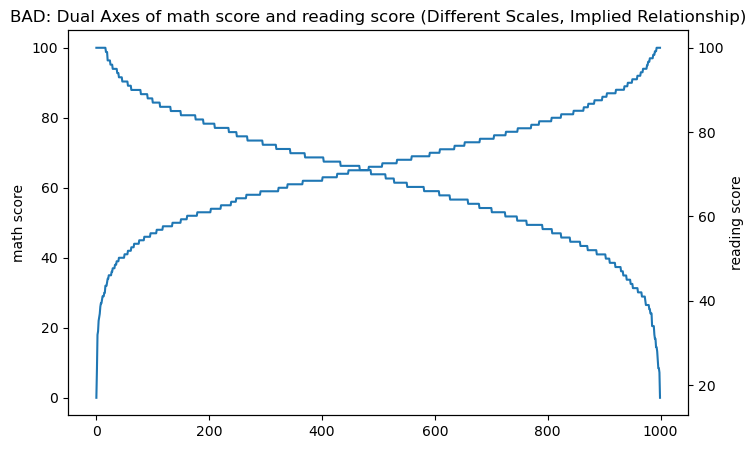

In [8]:

# BAD: Dual y-axes comparing unrelated measures
if len(num_cols) >= 2:
    a, b = num_cols[0], num_cols[1]
    s1 = df[a].sort_values().reset_index(drop=True)
    s2 = df[b].sort_values(ascending=False).reset_index(drop=True)  # opposite order for fake "relationship"
    x = np.arange(min(len(s1), len(s2)))

    fig, ax1 = plt.subplots()
    ax1.plot(x, s1)
    ax1.set_ylabel(a)

    ax2 = ax1.twinx()
    ax2.plot(x, s2)
    ax2.set_ylabel(b)
    plt.title(f'BAD: Dual Axes of {a} and {b} (Different Scales, Implied Relationship)')
    plt.show()
else:
    print("Need at least two numeric columns for this example.")



---
### Student Checklist (What to Submit)
- A short critique for **each** bad chart (1–2 paragraphs each).
- A **redesigned** version for at least **two** charts (clear, accessible, correct scale/axes).
- A brief **justification** for each redesign referencing Wilke’s principles and Module 8 content.
